# 05 - Ensemble Learning (CNN + EfficientNet-B0 + Swin-Tiny)

Combine the three trained models' probability outputs into a single
ensemble prediction. We try three combiners:

| Method | Formula | Tunable |
|---|---|---|
| Soft voting | `mean(p1, p2, p3)` | 0 params |
| Weighted average | `sum(w_i * p_i)` | weights `w_i` |
| Stacking | `LogReg([p1; p2; p3])` | sklearn meta-learner |

Outputs:
* `models/ensemble_config.json`                       — winning method + weights
* `outputs/confusion_matrices/ensemble_val_cm.png`
* `outputs/reports/ensemble_comparison.csv`           — all 4 (3 base + ensemble) head-to-head
* `outputs/plots/ensemble_weight_heatmap.png`         — grid-search visualization

In [1]:
# --- 0. Setup ---------------------------------------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / '__init__.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.config       import CLASS_NAMES, NUM_CLASSES, BATCH_SIZE, NUM_WORKERS, OUTPUTS_DIR, MODELS_DIR
from src.data_loader  import get_dataloaders
from src.ensemble     import (
    collect_probs, soft_voting, weighted_average, accuracy,
    find_optimal_weights, StackingEnsemble, EnsembleConfig,
    load_all_models,
)
from src.evaluate     import (
    build_classification_report, plot_confusion_matrix, per_class_metrics_df,
)
from src.utils        import get_device, set_seed

set_seed(42)
device = get_device()
sns.set_theme(style='whitegrid', context='notebook')
print(f'Device : {device}')

Device : cuda


## 1. Load all three trained models

In [2]:
models = load_all_models(
    device,
    cnn_path      = MODELS_DIR / 'cnn_model.pth',
    transfer_path = MODELS_DIR / 'transfer_model.pth',
    swin_path     = MODELS_DIR / 'swin_model.pth',
)
for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  {name:9s} -> {type(m).__name__:14s} ({n_params:,} params)')

  cnn       -> BrainTumorCNN  (1,206,628 params)
  transfer  -> TransferModel  (4,012,672 params)
  swin      -> SwinModel      (27,522,430 params)


## 2. Collect val-set probabilities from each model

Each inference pass is ~20 s on GTX 1650 (35 batches × ~0.5 s).

In [3]:
_, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)

probs_val = {}
labels_val = None
for name, m in models.items():
    p, y = collect_probs(m, val_loader, device, desc=f'{name} val')
    probs_val[name] = p
    if labels_val is None:
        labels_val = y
    else:
        # sanity check: same image order across models
        assert np.array_equal(labels_val, y), 'val labels disagree between models!'
    print(f'  {name:9s} -> probs shape {p.shape}, val_acc = {accuracy(p, y):.4f}')

prob_list_val = [probs_val['cnn'], probs_val['transfer'], probs_val['swin']]
model_names   = ['cnn', 'transfer', 'swin']

cnn val:   0%|          | 0/35 [00:15<?, ?it/s]

  cnn       -> probs shape (1120, 4), val_acc = 0.9036


transfer val:   0%|          | 0/35 [00:00<?, ?it/s]

  transfer  -> probs shape (1120, 4), val_acc = 0.9893


swin val:   0%|          | 0/35 [00:00<?, ?it/s]

  swin      -> probs shape (1120, 4), val_acc = 0.9670


## 3. Method 1 — Soft voting (equal weights)

Zero tuning, fully honest. The simplest possible ensemble.

In [4]:
probs_sv = soft_voting(prob_list_val)
acc_sv = accuracy(probs_sv, labels_val)
print(f'Soft voting val_acc = {acc_sv:.4f}')

Soft voting val_acc = 0.9750


## 4. Method 2 — Weighted averaging (grid search)

Searches all (w1, w2, w3) with each w_i in [0, 1] and sum=1 (step 0.05)
for the combination that maximizes val accuracy.

Best weights: w_cnn=0.00  w_transfer=0.90  w_swin=0.10
Weighted-avg val_acc = 0.9893


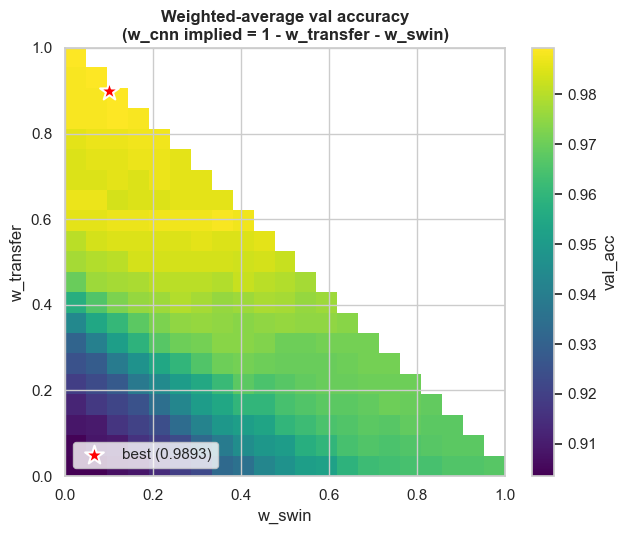

In [5]:
best_w, best_acc_w = find_optimal_weights(prob_list_val, labels_val, step=0.05)
print(f'Best weights: w_cnn={best_w[0]:.2f}  w_transfer={best_w[1]:.2f}  w_swin={best_w[2]:.2f}')
print(f'Weighted-avg val_acc = {best_acc_w:.4f}')

# Build a heatmap of accuracy across (w_transfer, w_swin) with w_cnn implied.
step = 0.05
grid = np.arange(0.0, 1.0 + step/2, step)
heat = np.full((len(grid), len(grid)), np.nan)
for i, w_tl in enumerate(grid):
    for j, w_sw in enumerate(grid):
        w_cn = 1.0 - w_tl - w_sw
        if w_cn < -1e-9 or w_cn > 1 + 1e-9:
            continue
        w_cn = max(0.0, w_cn)
        p = weighted_average(prob_list_val, [w_cn, w_tl, w_sw])
        heat[i, j] = accuracy(p, labels_val)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(heat, origin='lower', cmap='viridis',
               extent=[grid[0], grid[-1], grid[0], grid[-1]], aspect='auto')
ax.scatter(best_w[2], best_w[1], color='red', marker='*', s=200,
           edgecolor='white', linewidth=1.5, label=f'best ({best_acc_w:.4f})')
ax.set_xlabel('w_swin'); ax.set_ylabel('w_transfer')
ax.set_title('Weighted-average val accuracy\n(w_cnn implied = 1 - w_transfer - w_swin)',
             fontweight='bold')
fig.colorbar(im, ax=ax, label='val_acc')
ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / 'plots' / 'ensemble_weight_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Method 3 — Stacking (LogReg meta-learner)

Concatenate the three (N, 4) probability matrices into one (N, 12)
feature matrix and fit a logistic regression mapping (12 → 4 classes).

**Honest evaluation:** we 5-fold cross-validate so we never test on
data the stacker was trained on.

In [6]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = np.concatenate(prob_list_val, axis=1)   # (N, 12)
y = labels_val

cv_accs = []
for fold, (tr_idx, te_idx) in enumerate(kf.split(X), 1):
    stk = StackingEnsemble().fit(
        [p[tr_idx] for p in prob_list_val],
        y[tr_idx],
    )
    preds = stk.predict([p[te_idx] for p in prob_list_val])
    acc = float((preds == y[te_idx]).mean())
    cv_accs.append(acc)
    print(f'  fold {fold}  acc = {acc:.4f}')

acc_stack = float(np.mean(cv_accs))
print(f'\nStacking (5-fold CV mean) val_acc = {acc_stack:.4f}  +/- {np.std(cv_accs):.4f}')

# Also fit on full val to get final predictions for the confusion matrix.
stk_full = StackingEnsemble().fit(prob_list_val, y)
probs_stack = stk_full.predict_proba(prob_list_val)
print(f'Stacking (full-fit, optimistic) val_acc = {accuracy(probs_stack, y):.4f}')

  fold 1  acc = 0.9955
  fold 2  acc = 0.9732
  fold 3  acc = 0.9821
  fold 4  acc = 0.9911
  fold 5  acc = 0.9866

Stacking (5-fold CV mean) val_acc = 0.9857  +/- 0.0077
Stacking (full-fit, optimistic) val_acc = 0.9884


## 6. Pick the winner

In [7]:
candidates = [
    ('soft_voting',  acc_sv,       None),
    ('weighted',     best_acc_w,   best_w.tolist()),
    ('stacking',     acc_stack,    None),
]
name_win, acc_win, w_win = max(candidates, key=lambda t: t[1])
print(f'Winning method: {name_win}  (val_acc={acc_win:.4f})')

# Compute the final ensemble probabilities for the winner
if name_win == 'soft_voting':
    probs_ens = probs_sv
elif name_win == 'weighted':
    probs_ens = weighted_average(prob_list_val, w_win)
else:
    probs_ens = probs_stack

y_pred_ens = probs_ens.argmax(axis=1)

# Save the winning config
ec = EnsembleConfig(
    method      = name_win,
    model_names = model_names,
    weights     = w_win,
    metrics     = {
        'val_acc':     float(acc_win),
        'soft_voting': float(acc_sv),
        'weighted':    float(best_acc_w),
        'stacking_cv': float(acc_stack),
    },
    notes='Trained and tuned on the 1120-image stratified val split (STEP 3 split).',
)
ec.save(MODELS_DIR / 'ensemble_config.json')
print(f'\nSaved -> {MODELS_DIR / "ensemble_config.json"}')

Winning method: weighted  (val_acc=0.9893)

Saved -> C:\Brain Tumor Detection\models\ensemble_config.json


## 7. Final ensemble metrics — confusion matrix + classification report

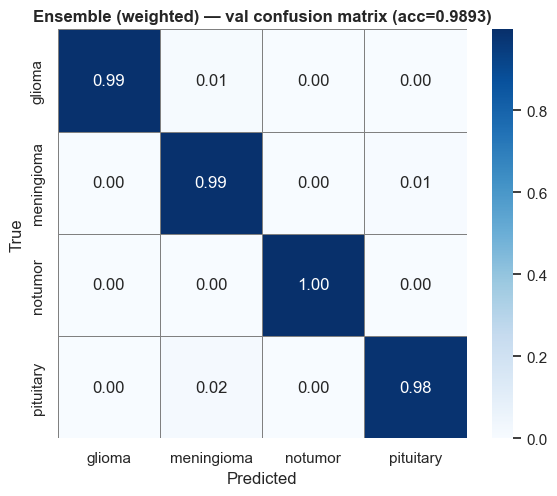

              precision    recall  f1-score   support

      glioma     0.9964    0.9893    0.9928       280
  meningioma     0.9685    0.9893    0.9788       280
     notumor     1.0000    0.9964    0.9982       280
   pituitary     0.9928    0.9821    0.9874       280

    accuracy                         0.9893      1120
   macro avg     0.9894    0.9893    0.9893      1120
weighted avg     0.9894    0.9893    0.9893      1120



In [8]:
fig = plot_confusion_matrix(
    labels_val, y_pred_ens, CLASS_NAMES, normalize=True,
    title=f'Ensemble ({name_win}) — val confusion matrix (acc={acc_win:.4f})',
    save_path=OUTPUTS_DIR / 'confusion_matrices' / 'ensemble_val_cm.png',
)
plt.show()

text, _ = build_classification_report(labels_val, y_pred_ens, CLASS_NAMES)
print(text)

## 8. Comparison — individual models vs ensemble

In [9]:
comparison = pd.DataFrame({
    'Model': [
        'Custom CNN', 'EfficientNet-B0', 'Swin-Tiny',
        'Ensemble (soft voting)', 'Ensemble (weighted)', 'Ensemble (stacking CV)',
        f'>>> WINNER: {name_win}',
    ],
    'Val accuracy': [
        round(accuracy(probs_val['cnn'],      labels_val), 4),
        round(accuracy(probs_val['transfer'], labels_val), 4),
        round(accuracy(probs_val['swin'],     labels_val), 4),
        round(acc_sv,       4),
        round(best_acc_w,   4),
        round(acc_stack,    4),
        round(acc_win,      4),
    ],
})
print(comparison.to_string(index=False))

comparison.to_csv(OUTPUTS_DIR / 'reports' / 'ensemble_comparison.csv', index=False)
print(f"\nSaved -> {OUTPUTS_DIR / 'reports' / 'ensemble_comparison.csv'}")

                 Model  Val accuracy
            Custom CNN        0.9036
       EfficientNet-B0        0.9893
             Swin-Tiny        0.9670
Ensemble (soft voting)        0.9750
   Ensemble (weighted)        0.9893
Ensemble (stacking CV)        0.9857
  >>> WINNER: weighted        0.9893

Saved -> C:\Brain Tumor Detection\outputs\reports\ensemble_comparison.csv


## 9. Summary

Artifacts produced by this notebook:

* `models/ensemble_config.json`                       — winning method + weights
* `outputs/confusion_matrices/ensemble_val_cm.png`    — ensemble CM on val
* `outputs/plots/ensemble_weight_heatmap.png`         — grid-search visualization
* `outputs/reports/ensemble_comparison.csv`           — all methods head-to-head

**Next:** STEP 15 — final evaluation on the held-out *test* set
(1,600 images, never seen during training or hyperparameter tuning).